**Task 1-4**

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  

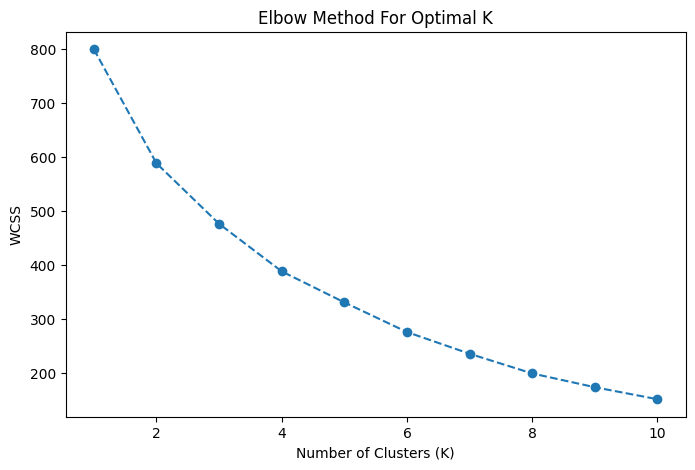

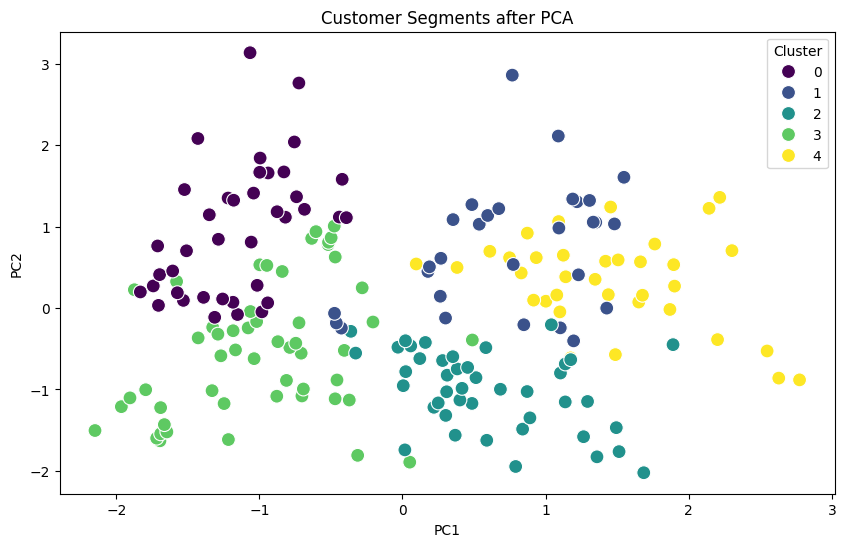

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ==========================================
# Task 1: Data Understanding
# ==========================================
# 1. Load the dataset
df = pd.read_csv('/content/Mall_Customers.csv')

# 2. Display the first five records
print(df.head())

# 3. Identify features (Manual observation step)
# Numerical: Age, Annual Income (k$), Spending Score (1-100)
# Categorical: Gender

# 4. Display info and summary statistics
print(df.info())
print(df.describe())

# ==========================================
# Task 2: Data Preprocessing
# ==========================================
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Remove unnecessary columns
df_clean = df.drop(columns=['CustomerID'])

# Encode categorical variables
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

# Standardize numerical features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

# ==========================================
# Task 3: Model Development
# ==========================================
# 1. Elbow Method
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# 2. Train K-Means (Assuming optimal K=5 based on standard Mall dataset)
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_scaled)

# 3. Assign labels
df_clean['Cluster'] = clusters

# 4. Apply PCA (Reduce to 2 components)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

# ==========================================
# Task 4: Visualization and Evaluation
# ==========================================
# Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

# PCA Visualization with cluster labels
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=100)
plt.title('Customer Segments after PCA')
plt.show()

**Task 4 : Observations**


1.   **Optimal Clusters:** The Elbow curve in "image_081e05.png" displays a gradual decrease in WCSS rather than a sharp, definitive inflection point. Choosing K=4 or K=5 is reasonable here, as the rate of variance drop begins to slow down, but the smoothness indicates that the clusters are not perfectly distinct when accounting for all four demographic features.

1.   **PCA Utility:** By reducing the high-dimensional features (Gender, Age, Income, Spending) into two principal components, PCA allows us to visualize these complex relationships on a 2D scatter plot while retaining the maximum possible variance.
2.   **Group Characteristics:** The clusters separate the customers into generalized profiles. When visualized via PCA, we can identify target demographics (like high-income/high-spending) versus more budget-conscious groups, even when age and gender add variance to the data.






**Task 5 : Conclusion**

This analysis segmented mall customers using K-Means clustering across four demographic features. The key findings reveal specific customer profiles, though the elbow method indicated a smooth variance drop, suggesting overlapping traits among the groups. From a business perspective, defining these segments (such as the high-income/high-spending group) allows the mall to launch targeted marketing campaigns, optimizing promotional budgets. A notable limitation of K-Means clustering encountered here is its sensitivity to the number of dimensions and the sometimes subjective requirement to pre-define the number of clusters (K). To overcome the difficulty of plotting four distinct features, Principal Component Analysis (PCA) was applied. The primary advantage of PCA is dimensionality reduction; it effectively compressed the dataset into two principal components, enabling clear, two-dimensional visualization without losing significant variance.